### Student = David Medina Rosner

### Id = F11115117


In [1]:
# libraries
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

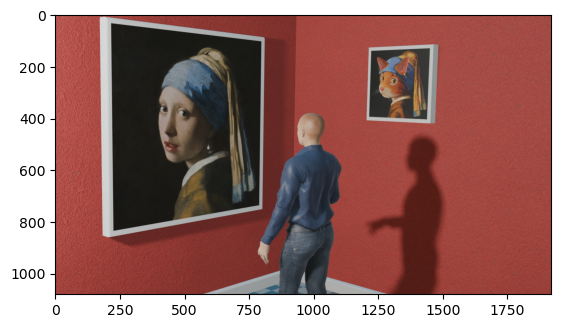

In [2]:
# open photo to swap
img_bgr = cv.imread('Swap_ArtGallery.jpg')
img = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)
spare_img = img.copy()

plt.imshow(spare_img)
plt.show()

In [3]:
left_painting = np.array([[218, 35],
                          [227, 835],
                          [789, 736],
                          [797, 107]])

right_painting = np.array([[1225, 143],
                           [1218, 395],
                           [1438, 405],
                           [1449, 133]])

# calculate x matrix, by using formula from lecture 3 (31~34)
matrix_x = []
for left, right in zip(left_painting, right_painting):
    x, y = left
    x_, y_ = right
    matrix_x.append([x, y, 1, 0, 0, 0, -x_*x, -x_*y])
    matrix_x.append([0, 0, 0, x, y, 1, -y_*x, -y_*y])
    
matrix_x = np.array(matrix_x)
print(matrix_x)

[[     218       35        1        0        0        0  -267050   -42875]
 [       0        0        0      218       35        1   -31174    -5005]
 [     227      835        1        0        0        0  -276486 -1017030]
 [       0        0        0      227      835        1   -89665  -329825]
 [     789      736        1        0        0        0 -1134582 -1058368]
 [       0        0        0      789      736        1  -319545  -298080]
 [     797      107        1        0        0        0 -1154853  -155043]
 [       0        0        0      797      107        1  -106001   -14231]]


In [4]:
matrix_x_ = right_painting.reshape(-1)
print(matrix_x_)

[1225  143 1218  395 1438  405 1449  133]


In [5]:
# calculate h matrix
matrix_h = np.linalg.inv(matrix_x) @ matrix_x_
matrix_h = np.concatenate([matrix_h, [1]])
matrix_h = matrix_h.reshape(3, 3)

print(matrix_h)

[[-2.69255650e-01 -3.11977580e-02  1.16968763e+03]
 [-1.07472539e-01  2.78082567e-01  1.43259724e+02]
 [-4.28320047e-04 -1.67733875e-05  1.00000000e+00]]


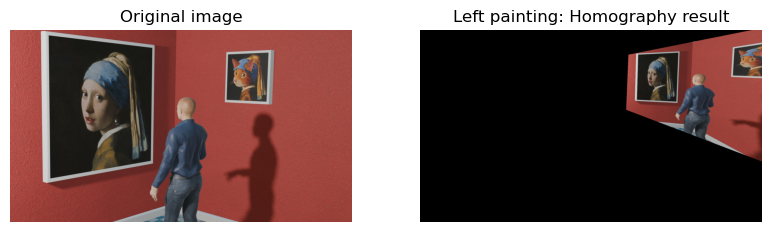

In [6]:
# perform homography on left painting, swaping to right side -------------------------------------------------------------- #
result = cv.warpPerspective(spare_img, matrix_h, (spare_img.shape[1], spare_img.shape[0]))

fig = plt.figure(figsize=(15, 5))

# original image
fig.add_subplot(131)
plt.title("Original image")
plt.axis('off')
plt.imshow(spare_img)

# left painting projected to right side
fig.add_subplot(132)
plt.title("Left painting: Homography result")
plt.axis('off')
plt.imshow(result)
plt.show()

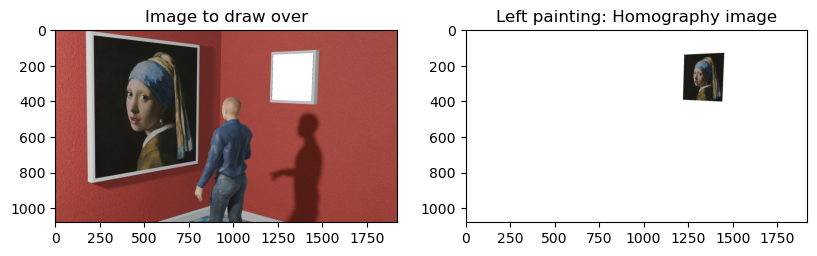

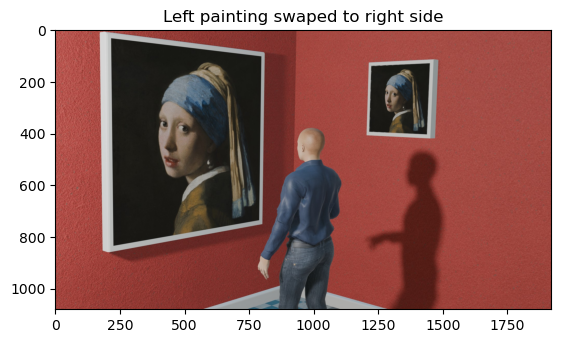

In [7]:
# image in which to draw the homography result of left painting
roi_corners = right_painting
black = (255, 255, 255)

img_to_draw_over = cv.fillConvexPoly(spare_img, points=roi_corners, color=black)

fig = plt.figure(figsize=(15, 5))

fig.add_subplot(131) # show image
plt.title("Image to draw over")
plt.imshow(img_to_draw_over)


# create a mask with white pixels
mask = np.ones(result.shape, dtype=np.uint8)
mask.fill(255)

white = (0, 0, 0)
roi_img = cv.fillConvexPoly(mask, points=roi_corners, color=white)

# apply the mask to the homography result
homography_img = cv.bitwise_or(result, roi_img)

fig.add_subplot(132) # show image
plt.title("Left painting: Homography image")
plt.imshow(homography_img)
plt.show()


# draw homography image over original image
final_img = cv.bitwise_and(img_to_draw_over, homography_img)

plt.title("Left painting swaped to right side") # show image
plt.imshow(final_img)
plt.show()

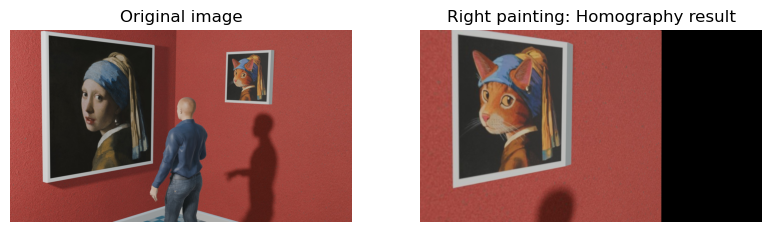

In [8]:
# perform homography on right painting, swaping to left side -------------------------------------------------------------- #
spare_img = img.copy()
inv_matrix_h = np.linalg.inv(matrix_h)

result = cv.warpPerspective(spare_img, inv_matrix_h, (spare_img.shape[1], spare_img.shape[0]))

fig = plt.figure(figsize=(15, 5))

# original image
fig.add_subplot(131)
plt.title("Original image")
plt.axis('off')
plt.imshow(spare_img)

# right painting projected to left side
fig.add_subplot(132)
plt.title("Right painting: Homography result")
plt.axis('off')
plt.imshow(result)
plt.show()

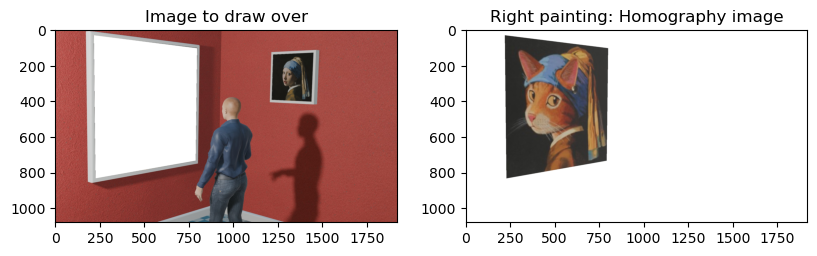

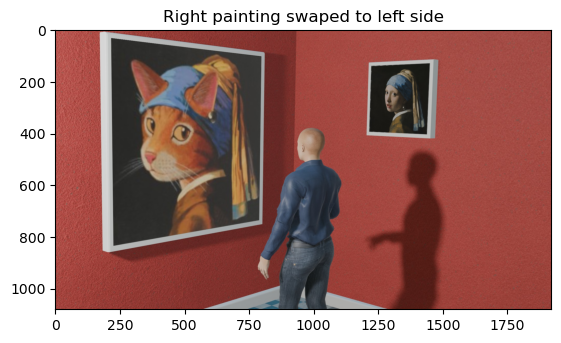

In [9]:
# image in which to draw the homography result of right painting
roi_corners = left_painting
black = (255, 255, 255)

img_to_draw_over = cv.fillConvexPoly(final_img, points=roi_corners, color=black)

fig = plt.figure(figsize=(15, 5))

fig.add_subplot(131) # show image
plt.title("Image to draw over")
plt.imshow(img_to_draw_over)


# create a mask with white pixels
mask = np.ones(result.shape, dtype=np.uint8)
mask.fill(255)

white = (0, 0, 0)
roi_img = cv.fillConvexPoly(mask, points=roi_corners, color=white)

# apply the mask to the homography result
homography_img = cv.bitwise_or(result, roi_img)

fig.add_subplot(132) # show image
plt.title("Right painting: Homography image")
plt.imshow(homography_img)
plt.show()


# draw homography image over original image
final_img = cv.bitwise_and(img_to_draw_over, homography_img)

plt.title("Right painting swaped to left side") # show image
plt.imshow(final_img)
plt.show()

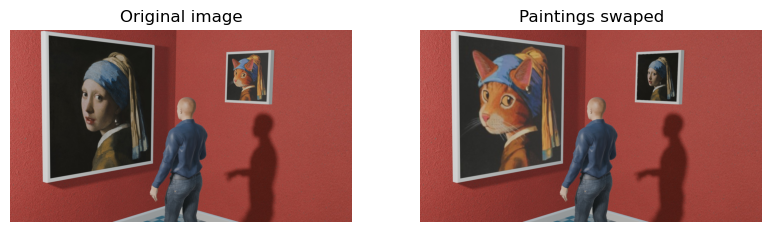

True

In [10]:
# final comparision
fig = plt.figure(figsize=(15, 5))

# original image
fig.add_subplot(131)
plt.title("Original image")
plt.axis('off')
plt.imshow(img)

# image with paintings swaped
fig.add_subplot(132)
plt.title("Paintings swaped")
plt.axis('off')
plt.imshow(final_img)
plt.show()

# save final image
img_2_save = cv.cvtColor(final_img, cv.COLOR_RGB2BGR)
cv.imwrite('F11115117.jpg', img_2_save)  